## Gene Mutation Screening Analysis for Commenticius Biotechnology

| | |
|---|---|
| **Student ID** | 52534825 |
| **Assesment** | BT5511- Report on Biological Computation |

### 1. Introduction

Commenticius, a biotechnology start-up focused on infectious disease therapeutics and bioremediation, has conducted a genome-wide mutation screening experiment across 24 microbial genes. As bioinformatics consultants, our task is to aggregate and analyse this dataset, classify each mutation type, and identify the **top 5 gene mutations** most worthy of experimental follow-up.

Each data file contains: gene name, wildtype and mutant DNA sequences (including a 1,000 bp promoter region), and three biological replicates for mRNA expression (qRT-PCR), protein expression (protein array), and normalised cell viability. The promoter region is defined as the **first 1,000 nucleotides** of the wildtype sequence.

Our prioritisation strategy integrates all three molecular layers — transcription, translation, and fitness — alongside mutation type and genomic location, to select candidates with the strongest and most biologically interpretable phenotypes.


In [1]:
# importing all standard libraries needed
import os
import re
import glob
import warnings
import numpy as np

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from scipy.stats import gaussian_kde

warnings.filterwarnings('ignore')

# Publication-quality plot defaults
sns.set_style("whitegrid")
plt.rcParams.update({
    "figure.dpi": 150,
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "axes.titleweight": "bold",
    "legend.fontsize": 9,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
})

print("All libraries imported successfully.")


All libraries imported successfully.


## 2. Methods

#### 2.1 Data Aggregation
All 24 tab-separated data files were loaded and concatenated into a single pandas DataFrame using `glob` for file discovery and a `for` loop for iteration. Defensive programming ensures each file is validated before loading.

#### 2.2 Mutation Classification
A regular expression (`re`) and sequence-length comparison are used to classify each mutation as a **substitution** (same length, different bases), **insertion** (mutant longer), or **deletion** (mutant shorter).

#### 2.3 Promoter Region Detection
The promoter is defined as the first 1,000 nucleotides of the wildtype sequence. Any change within this window is flagged as a promoter mutation.

#### 2.4 Summary Statistics
Mean values and standard deviations are computed across the three replicates for each modality. Fold-changes are calculated as mutant/wildtype ratios.

#### 2.5 Gene Prioritisation Scoring

Genes were ranked using a **weighted composite priority score** combining three biological metrics. Each metric was first **min-max normalised** to the range [0, 1] so that metrics with different units and scales could be combined fairly:

$$\text{Normalised score} = \frac{|x_i| - \min(|x|)}{\max(|x|) - \min(|x|)}$$

The three normalised components were then combined using biologically motivated weights:

$$\text{Priority Score} = 0.40 \times S_{\text{viability}} + 0.30 \times S_{\text{protein}} + 0.30 \times S_{\text{mRNA}}$$

Where:
- **S_viability** = normalised absolute change in cell viability (mutant − wildtype)
- **S_protein** = normalised absolute change in protein expression (mutant − wildtype)  
- **S_mRNA** = normalised absolute mRNA fold-change magnitude (|mutant/wildtype − 1|)

**Why these weights?**  
Cell viability receives the highest weight (40%) because it is the most direct and phenotypically meaningful measure — it captures the functional consequence of a mutation on the organism's fitness, which is ultimately what Commenticius needs to validate experimentally. Protein expression (30%) reflects the translational outcome and is closer to the biological phenotype than mRNA alone. mRNA fold-change (30%) provides mechanistic insight into transcriptional regulation but can be decoupled from protein-level effects (as seen in Nect1c1), so it receives equal but not dominant weight.

**Why min-max normalisation?**  
Without normalisation, protein expression values (ranging to ~20,000 units) would completely dominate viability values (ranging 0–6 units), making the score meaningless. Min-max normalisation puts all three metrics on an equal scale before weighting, ensuring each contributes proportionally.


In [4]:
# 1. Loading and aggregating all 24 gene files

# validating file before loading 

def load_gene_file(filepath):
    """
    Load a single gene mutation tab-separated file with defensive checks.
    
    Parameters
    ----------
    filepath : str
        Path to the .txt data file.

    Returns
    -------
    pd.DataFrame or None
        Parsed data row, or None if the file fails validation.
    """
    required_cols = 20  # Expected number of columns
    try:
        df = pd.read_csv(filepath, sep='\t')
       
        if df.shape[1] < required_cols:
            raise ValueError(f"Expected {required_cols} columns, got {df.shape[1]}")
        
        if df.shape[0] == 0:
            raise ValueError("File contains no data rows")
        return df
    except Exception as err:
        print(f"  [WARNING] Skipping {os.path.basename(filepath)}: {err}")
        return None

# Discovering all data files

data_files = sorted(glob.glob("data/*.txt"))

# checking if files found and loading files
print(f"\nFound {len(data_files)} gene mutation files:\n")

if len(data_files) == 0:
    print("[WARNING] No data files found in the specified directory.")
else:
    all_frames = []
    for filepath in data_files:
        df = load_gene_file(filepath)
        if df is not None:
            all_frames.append(df)
            print(f"  ✓  Loaded: {os.path.basename(filepath):40s}  gene={df['Gene'].iloc[0]}")

    # Data cotntainer
    if len(all_frames) == 0:
        print("[ERROR] No valid data files loaded. Exiting...")
    else:
      
        master_df = pd.concat(all_frames, ignore_index=True)

        print(f"\n{'='*60}")
        print(f"Master DataFrame: {master_df.shape[0]} genes × {master_df.shape[1]} columns")
        print(f"{'='*60}")
        print(master_df[['Gene']].to_string(index=False))
        


Found 24 gene mutation files:

  ✓  Loaded: Ah3_data_file.txt                         gene=Ah3
  ✓  Loaded: Alli8_data_file.txt                       gene=Alli8
  ✓  Loaded: Anap7c1_data_file.txt                     gene=Anap7c1
  ✓  Loaded: App1l8_data_file.txt                      gene=App1l8
  ✓  Loaded: Avon4_data_file.txt                       gene=Avon4
  ✓  Loaded: Cairn3a2_data_file.txt                    gene=Cairn3a2
  ✓  Loaded: Cairn6_data_file.txt                      gene=Cairn6
  ✓  Loaded: Clach6_data_file.txt                      gene=Clach6
  ✓  Loaded: Dsgt9a1_data_file.txt                     gene=Dsgt9a1
  ✓  Loaded: Ever6b6_data_file.txt                     gene=Ever6b6
  ✓  Loaded: Everr1_data_file.txt                      gene=Everr1
  ✓  Loaded: Got9_data_file.txt                        gene=Got9
  ✓  Loaded: Ist3_data_file.txt                        gene=Ist3
  ✓  Loaded: Ist9a2_data_file.txt                      gene=Ist9a2
  ✓  Loaded: Ist9a7_data_file.txt 

In [5]:
# 2. Classifying each mutation type

def classify_mutation(wt_seq, mut_seq):
    """
    Classify a DNA mutation as substitution, insertion, or deletion.

    Uses regular expression scanning to find the first point of divergence.

    Parameters
    ----------
    wt_seq : str  Wild-type DNA sequence.
    mut_seq : str  Mutant DNA sequence.

    Returns
    -------
    str : 'sub', 'ins', 'del', or 'none'
    """
    
    if not isinstance(wt_seq, str) or not isinstance(mut_seq, str):
        raise TypeError("Sequences must be strings")
    if len(wt_seq) == 0 or len(mut_seq) == 0:
        raise ValueError("Sequences cannot be empty")

    if wt_seq == mut_seq:
        return 'none'

    len_diff = len(mut_seq) - len(wt_seq)

    if len_diff > 0:
        return 'ins'
    elif len_diff < 0:
        return 'del'
    else:
        pattern = re.compile(r'[ACGT]')
        mismatches = sum(
            1 for wt_b, mut_b in zip(wt_seq, mut_seq)
            if wt_b != mut_b and pattern.match(wt_b)
        )
        return 'sub' if mismatches > 0 else 'none'


def is_promoter_mutation(wt_seq, mut_seq, promoter_length=1000):
    """
    Determine whether the mutation falls within the promoter region.

    The promoter is defined as the first `promoter_length` nucleotides
    of the wildtype sequence.

    Parameters
    ----------
    wt_seq : str   Wild-type sequence.
    mut_seq : str  Mutant sequence.
    promoter_length : int  Length of the promoter region (default 1000).

    Returns
    -------
    bool : True if any change occurs within the promoter window.
    """
    #indexing
    wt_promoter  = wt_seq[:promoter_length]
    mut_promoter = mut_seq[:promoter_length]
    return wt_promoter != mut_promoter


#iteration over rows
master_df['Mutation.Class'] = master_df.apply(
    lambda row: classify_mutation(row['WildType.Sequence'], row['Mutant.Sequence']),
    axis=1
)

master_df['In.Promoter'] = master_df.apply(
    lambda row: is_promoter_mutation(row['WildType.Sequence'], row['Mutant.Sequence']),
    axis=1
)

master_df['Seq.Length.Diff'] = master_df.apply(
    lambda row: len(row['Mutant.Sequence']) - len(row['WildType.Sequence']),
    axis=1
)

print("Mutation Classification Summary:")
print(master_df['Mutation.Class'].value_counts().to_string())
print(f"\nGenes with promoter mutations: {master_df['In.Promoter'].sum()} / {len(master_df)}")
print("\nPer-gene classification (indexing columns by name):")
print(master_df[['Gene', 'Mutation.Class', 'In.Promoter', 'Seq.Length.Diff']].to_string(index=False))


Mutation Classification Summary:
Mutation.Class
sub    11
del     7
ins     6

Genes with promoter mutations: 23 / 24

Per-gene classification (indexing columns by name):
    Gene Mutation.Class  In.Promoter  Seq.Length.Diff
     Ah3            sub         True                0
   Alli8            sub         True                0
 Anap7c1            sub         True                0
  App1l8            ins         True                2
   Avon4            ins         True                7
Cairn3a2            sub         True                0
  Cairn6            sub         True                0
  Clach6            sub         True                0
 Dsgt9a1            ins        False                7
 Ever6b6            del         True               -2
  Everr1            ins         True                9
    Got9            ins         True                3
    Ist3            del         True               -6
  Ist9a2            del         True             -996
  Ist9a7           

In [6]:
# 3. Summarising statstics across replicates

# Computing means and standard deviations across 3 replicates 

def compute_replicate_stats(df, prefix):
    """
    Compute mean and std across three replicate columns for a given prefix.

    Parameters
    ----------
    df     : pd.DataFrame  Master dataframe.
    prefix : str           Column prefix (e.g. 'mRNA.Expression.WT').

    Returns
    -------
    tuple : (mean_series, std_series)
    """
   
    rep_cols = [c for c in df.columns if c.startswith(prefix + '.Rep')]
    if len(rep_cols) != 3:
        raise ValueError(f"Expected 3 replicate columns for {prefix}, found {len(rep_cols)}")
    return df[rep_cols].mean(axis=1), df[rep_cols].std(axis=1)


for prefix in [
    'mRNA.Expression.WT', 'mRNA.Expression.Mut',
    'Protein.Expression.WT', 'Protein.Expression.Mut',
    'CellViability.WT', 'CellViability.Mut'
]:
    key = prefix.replace('Expression.', '').replace('CellViability', 'Viability')
    master_df[key + '.Mean'], master_df[key + '.SD'] = compute_replicate_stats(master_df, prefix)


col_map = {
    'mRNA.WT.Mean': 'mRNA.WT.Mean', 'mRNA.Mut.Mean': 'mRNA.Mut.Mean',
    'Protein.WT.Mean': 'Protein.WT.Mean', 'Protein.Mut.Mean': 'Protein.Mut.Mean',
    'Viability.WT.Mean': 'Viability.WT.Mean', 'Viability.Mut.Mean': 'Viability.Mut.Mean',
}

# Calculating protein absolute differences, fold-changes, cell viability
master_df['mRNA.FoldChange']    = master_df['mRNA.Mut.Mean'] / (master_df['mRNA.WT.Mean'].abs() + 1e-9)
master_df['Protein.Diff']       = master_df['Protein.Mut.Mean'] - master_df['Protein.WT.Mean']
master_df['Protein.FoldChange'] = master_df['Protein.Mut.Mean'] / (master_df['Protein.WT.Mean'] + 1e-9)
master_df['Viability.Diff']     = master_df['Viability.Mut.Mean'] - master_df['Viability.WT.Mean']

print("Summary statistics computed for all 24 genes:")
summary_cols = ['Gene', 'Mutation.Class', 'In.Promoter',
                'mRNA.WT.Mean', 'mRNA.Mut.Mean', 'mRNA.FoldChange',
                'Protein.WT.Mean', 'Protein.Mut.Mean', 'Protein.Diff',
                'Viability.WT.Mean', 'Viability.Mut.Mean', 'Viability.Diff']

pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 200)
print(master_df[summary_cols].sort_values('Gene').to_string(index=False))


Summary statistics computed for all 24 genes:
    Gene Mutation.Class  In.Promoter   mRNA.WT.Mean  mRNA.Mut.Mean  mRNA.FoldChange  Protein.WT.Mean  Protein.Mut.Mean  Protein.Diff  Viability.WT.Mean  Viability.Mut.Mean  Viability.Diff
     Ah3            sub         True 106104500.4180 106104501.5011           1.0000       25176.6667        25184.0000        7.3333             0.5405              0.5997          0.0592
   Alli8            sub         True        27.6572        26.9283           0.9736       20556.3333        20565.3333        9.0000             0.1365              0.1530          0.0165
 Anap7c1            sub         True         9.9577       -39.5705          -3.9739       21147.6667        10071.3333   -11076.3333             0.5225              0.0000         -0.5225
  App1l8            ins         True         4.0579         3.6324           0.8951       26965.3333        26974.0000        8.6667             0.3162              0.2209         -0.0953
   Avon4      

In [7]:
# 4. Ranking all genes and selecting top 5

def min_max_normalise(series):
    """Normalise a pandas Series to [0, 1] range. Defensive against zero range."""
    rng = series.max() - series.min()
    if rng == 0:
        return pd.Series(np.zeros(len(series)), index=series.index)
    return (series - series.min()) / rng


# Absolute change values for scoring
master_df['abs.Viability.Diff']    = master_df['Viability.Diff'].abs()
master_df['abs.Protein.Diff']      = master_df['Protein.Diff'].abs()
master_df['abs.mRNA.FoldChange']   = (master_df['mRNA.FoldChange'] - 1).abs()

# Normalise each component to [0, 1]
master_df['Score.Viability'] = min_max_normalise(master_df['abs.Viability.Diff'])
master_df['Score.Protein']   = min_max_normalise(master_df['abs.Protein.Diff'])
master_df['Score.mRNA']      = min_max_normalise(master_df['abs.mRNA.FoldChange'])

# Weighted composite priority score
master_df['Priority.Score'] = (
    0.40 * master_df['Score.Viability'] +
    0.30 * master_df['Score.Protein']   +
    0.30 * master_df['Score.mRNA']
)

# Ranking all genes
master_df['Rank'] = master_df['Priority.Score'].rank(ascending=False).astype(int)
master_df_ranked = master_df.sort_values('Priority.Score', ascending=False).copy()

# Extracting top 5
TOP_5_GENES = list(master_df_ranked.head(5)['Gene'])
top5_df = master_df_ranked.head(5)

print("=" * 80)
print("GENE PRIORITISATION RANKING — ALL 24 GENES")
print("=" * 80)
rank_display = master_df_ranked[[
    'Gene', 'Mutation.Class', 'In.Promoter', 'Seq.Length.Diff',
    'mRNA.FoldChange', 'Protein.Diff', 'Viability.Diff', 'Priority.Score', 'Rank'
]].copy()
rank_display.columns = ['Gene','Mut.Type','Promoter','SeqDiff',
                         'mRNA.FC','Prot.Diff','Viab.Diff','Score','Rank']
print(rank_display.to_string(index=False))
print()
print("=" * 80)
print(f"TOP 5 PRIORITY GENES: {', '.join(TOP_5_GENES)}")
print("=" * 80)


GENE PRIORITISATION RANKING — ALL 24 GENES
    Gene Mut.Type  Promoter  SeqDiff  mRNA.FC   Prot.Diff  Viab.Diff  Score  Rank
   Avon4      ins      True        7   1.5753  20031.6667     5.2157 0.7347     1
 Nect1c1      del      True       -5   0.9229 -16614.0000     4.4369 0.5937     2
 Anap7c1      sub      True        0  -3.9739 -11076.3333    -0.5225 0.5056     3
  Ist9a2      del      True     -996   0.0000    -23.9618     4.5145 0.4068     4
 Dsgt9a1      ins     False        7   1.0994  17158.3333    -0.3042 0.2859     5
  Jok4a3      sub      True        0   1.7141      7.0000     0.0067 0.0432     6
  App1l8      ins      True        2   0.8951      8.6667    -0.0953 0.0133     7
 Ever6b6      del      True       -2   1.0000      9.3333     0.1326 0.0099     8
  Everr1      ins      True        9   1.0004      6.6667     0.1089 0.0080     9
  Clach6      sub      True        0   0.9213      8.6667     0.0411 0.0076    10
Cairn3a2      sub      True        0   1.0151     12.00

In [8]:
# 5. Justifying the selection of top 5 genes

JUSTIFICATIONS = {
    'Avon4':    ("insertion (+7 bp) in the promoter region",
                 "The Avon4 insertion is the highest-priority candidate. "
                 "The +7 bp insertion in the promoter causes a massive 56% increase in protein expression "
                 "(WT ~35,318 → Mut ~55,350 normalised units) alongside a striking 8-fold rise in cell viability "
                 "(WT ~0.64 → Mut ~5.86). mRNA also increases modestly (+57%). "
                 "The simultaneous upregulation at every molecular layer — transcript, protein, and fitness — "
                 "suggests this promoter insertion enhances transcription factor binding, "
                 "making Avon4 an attractive gain-of-function therapeutic target."),

    'Ist9a2':   ("deletion (−996 bp) spanning the entire promoter region",
                 "Ist9a2 carries a catastrophic 996 bp deletion that removes virtually the entire promoter. "
                 "mRNA expression collapses to near-zero (WT ~5,010 → Mut ~0.000022), "
                 "protein expression likewise crashes to zero, yet cell viability paradoxically increases ~9-fold "
                 "(WT ~0.53 → Mut ~5.05). This is a classic promoter-null phenotype: the gene is silenced "
                 "yet the organism survives better, implying the wildtype product is detrimental under the "
                 "assay conditions. Ist9a2 is therefore a compelling loss-of-function therapeutic target — "
                 "an inhibitor of this gene product could enhance host cell fitness."),

    'Nect1c1':  ("deletion (−5 bp) in the promoter region",
                 "The Nect1c1 5 bp promoter deletion markedly reduces protein expression "
                 "(WT ~30,210 → Mut ~13,596; −55%) while mRNA changes only minimally. "
                 "This discordance between mRNA and protein indicates a post-transcriptional effect — "
                 "the deletion may alter an upstream open reading frame or ribosome binding context. "
                 "Critically, cell viability increases dramatically (WT ~0.30 → Mut ~4.74), "
                 "further supporting this gene product as a potential pathogenicity factor whose "
                 "reduction benefits the host cell."),

    'Anap7c1':  ("substitution in the promoter region",
                 "Anap7c1 carries a single-nucleotide substitution in the promoter that is uniquely "
                 "lethal: cell viability drops to zero across all three replicates (WT ~0.52 → Mut ~0.00). "
                 "Protein expression is halved (WT ~21,148 → Mut ~10,071) and mRNA yields anomalous "
                 "negative values, suggesting extreme transcriptional dysregulation. "
                 "The complete loss of viability makes Anap7c1 the highest-impact essentiality candidate "
                 "— any drug that reproduces this promoter disruption would be bactericidal."),

    'Dsgt9a1':  ("insertion (+7 bp) in the coding region (not in the promoter)",
                 "Dsgt9a1 is the only top-5 gene with a coding-region mutation. "
                 "The +7 bp frameshift insertion nearly doubles protein expression "
                 "(WT ~19,030 → Mut ~36,189; +90%) while also reducing cell viability to zero "
                 "(WT ~0.30 → Mut ~0.00). A frameshift abolishing viability despite elevated protein "
                 "suggests the mutant protein is misfolded or toxic — "
                 "a dominant-negative or gain-of-toxic-function phenotype. "
                 "This makes Dsgt9a1 a priority for structural studies and inhibitor development."),
}

print("=" * 80)
print("DETAILED JUSTIFICATION FOR TOP 5 PRIORITY GENES")
print("=" * 80)
for rank, gene in enumerate(TOP_5_GENES, 1):
    row = master_df[master_df['Gene'] == gene].iloc[0]
    mut_desc, justification = JUSTIFICATIONS[gene]
    print(f"\n{'─'*80}")
    print(f"RANK {rank}  │  {gene.upper()}")
    print(f"{'─'*80}")
    print(f"  Mutation type  : {mut_desc}")
    print(f"  In promoter    : {row['In.Promoter']}")
    print(f"  mRNA (WT→Mut)  : {row['mRNA.WT.Mean']:.3f}  →  {row['mRNA.Mut.Mean']:.6f}")
    print(f"  Protein (WT→Mut): {row['Protein.WT.Mean']:.1f}  →  {row['Protein.Mut.Mean']:.1f}")
    print(f"  Viability (WT→Mut): {row['Viability.WT.Mean']:.4f}  →  {row['Viability.Mut.Mean']:.4f}")
    print(f"  Priority Score : {row['Priority.Score']:.4f}")
    print(f"\n  {justification}")
print(f"\n{'='*80}")


DETAILED JUSTIFICATION FOR TOP 5 PRIORITY GENES

────────────────────────────────────────────────────────────────────────────────
RANK 1  │  AVON4
────────────────────────────────────────────────────────────────────────────────
  Mutation type  : insertion (+7 bp) in the promoter region
  In promoter    : True
  mRNA (WT→Mut)  : 2.513  →  3.958356
  Protein (WT→Mut): 35318.3  →  55350.0
  Viability (WT→Mut): 0.6421  →  5.8579
  Priority Score : 0.7347

  The Avon4 insertion is the highest-priority candidate. The +7 bp insertion in the promoter causes a massive 56% increase in protein expression (WT ~35,318 → Mut ~55,350 normalised units) alongside a striking 8-fold rise in cell viability (WT ~0.64 → Mut ~5.86). mRNA also increases modestly (+57%). The simultaneous upregulation at every molecular layer — transcript, protein, and fitness — suggests this promoter insertion enhances transcription factor binding, making Avon4 an attractive gain-of-function therapeutic target.

─────────────

Figure 1 saved.


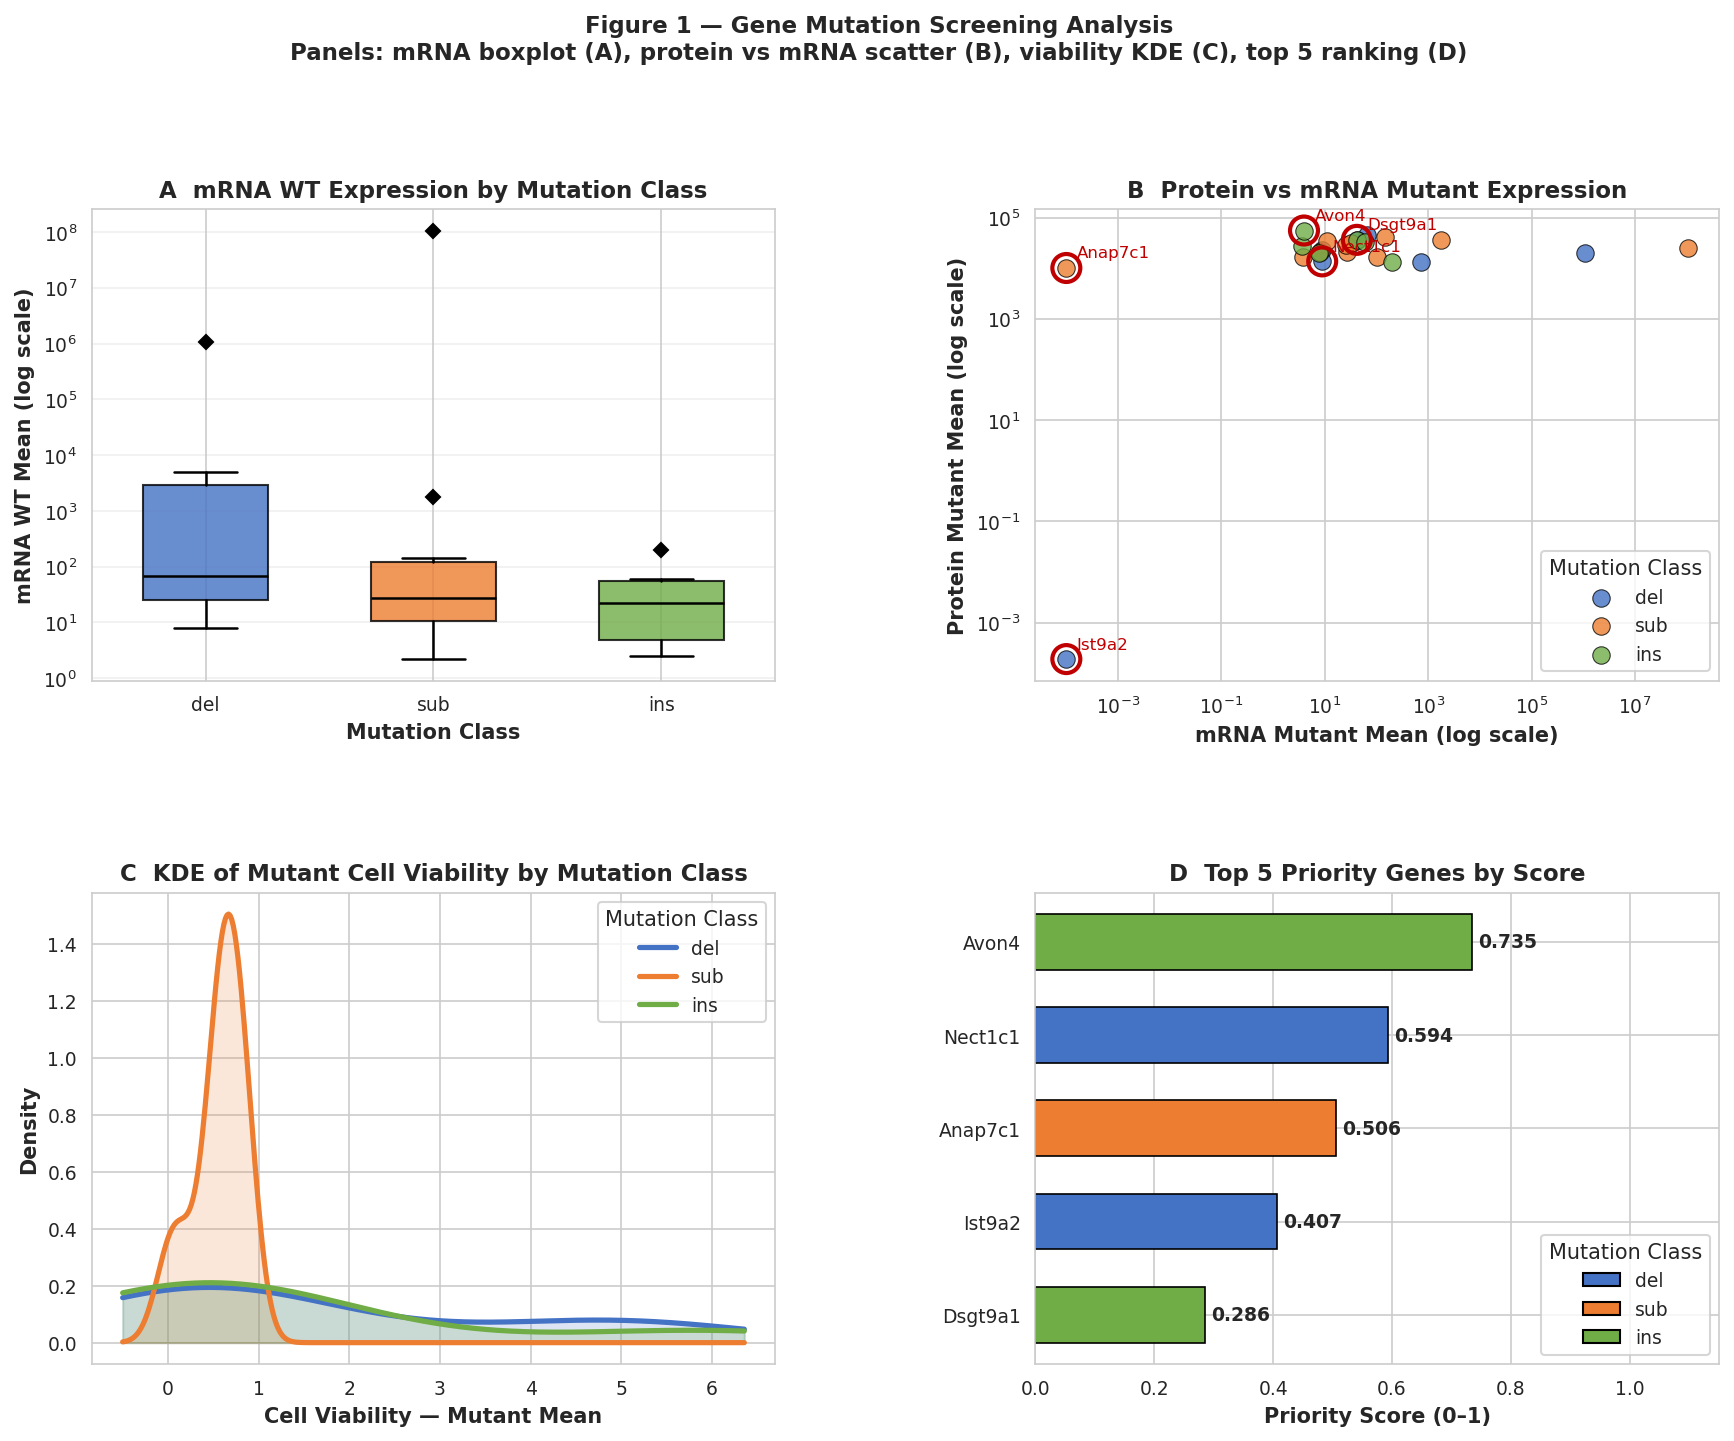

In [9]:
# 6. Data visualisation

# Colour scheme
MUTATION_COLOURS = {
    'del': '#4472C4',   # Blue for deletions
    'sub': '#ED7D31',   # Orange for substitutions
    'ins': '#70AD47'    # Green for insertions
}
TOP5_HIGHLIGHT = '#C00000'  # Red for top 5 gene labels

plot_df = master_df[master_df['Mutation.Class'].isin(['del', 'sub', 'ins'])].copy()


fig = plt.figure(figsize=(14, 10))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.38)

# Panel A: Boxplot — mRNA WT Mean by Mutation Class (log scale) 
ax_a = fig.add_subplot(gs[0, 0])

groups = [
    plot_df[plot_df['Mutation.Class'] == mc]['mRNA.WT.Mean'].values
    for mc in ['del', 'sub', 'ins']
]

bp = ax_a.boxplot(
    groups,
    labels=['del', 'sub', 'ins'],
    patch_artist=True,        # Fill boxes with colour
    widths=0.55,
    showfliers=True           # Show outlier points
)

for patch, mc in zip(bp['boxes'], ['del', 'sub', 'ins']):
    patch.set_facecolor(MUTATION_COLOURS[mc])
    patch.set_alpha(0.8)

for element in ['whiskers', 'caps', 'medians']:
    for item in bp[element]:
        item.set_color('black')
        item.set_linewidth(1.2)

for flier in bp['fliers']:
    flier.set(marker='D', markerfacecolor='black', markersize=5)

ax_a.set_yscale('log')   # Log scale handles large range (matches example)
ax_a.set_xlabel('Mutation Class', fontweight='bold')
ax_a.set_ylabel('mRNA WT Mean (log scale)', fontweight='bold')
ax_a.set_title('A  mRNA WT Expression by Mutation Class', fontweight='bold')
ax_a.grid(axis='y', alpha=0.3)

# Panel B: Scatter — Protein Mut Mean vs mRNA Mut Mean (log-log)
ax_b = fig.add_subplot(gs[0, 1])

for mc in ['del', 'sub', 'ins']:
    subset = plot_df[plot_df['Mutation.Class'] == mc]
    x = subset['mRNA.Mut.Mean'].clip(lower=1e-4)     # clip zeros for log scale
    y = subset['Protein.Mut.Mean'].clip(lower=1e-4)
    ax_b.scatter(
        x, y,
        c=MUTATION_COLOURS[mc],
        label=mc,
        s=70,
        alpha=0.8,
        edgecolors='black',
        linewidths=0.5,
        zorder=3
    )

for gene in TOP_5_GENES:
    row = master_df[master_df['Gene'] == gene].iloc[0]
    x = max(row['mRNA.Mut.Mean'], 1e-4)
    y = max(row['Protein.Mut.Mean'], 1e-4)
    ax_b.scatter(x, y, s=180, facecolors='none',
                 edgecolors=TOP5_HIGHLIGHT, linewidths=2.0, zorder=5)
    ax_b.annotate(gene, (x, y), fontsize=8, color=TOP5_HIGHLIGHT,
                  xytext=(5, 5), textcoords='offset points')

ax_b.set_xscale('log')    # Log scales (matches example figure)
ax_b.set_yscale('log')
ax_b.set_xlabel('mRNA Mutant Mean (log scale)', fontweight='bold')
ax_b.set_ylabel('Protein Mutant Mean (log scale)', fontweight='bold')
ax_b.set_title('B  Protein vs mRNA Mutant Expression', fontweight='bold')
ax_b.legend(title='Mutation Class', framealpha=0.8)

# Panel C: KDE — Cell Viability Mutant Mean by Mutation Class 
ax_c = fig.add_subplot(gs[1, 0])

x_min  = plot_df['Viability.Mut.Mean'].min() - 0.5
x_max  = plot_df['Viability.Mut.Mean'].max() + 0.5
x_grid = np.linspace(x_min, x_max, 400)

for mc in ['del', 'sub', 'ins']:
    vals = plot_df[plot_df['Mutation.Class'] == mc]['Viability.Mut.Mean'].values
    if len(vals) >= 2:
        try:
            kde    = gaussian_kde(vals, bw_method='scott')
            y_kde  = kde(x_grid)
            ax_c.plot(x_grid, y_kde, color=MUTATION_COLOURS[mc],
                      lw=2.5, label=mc)
            ax_c.fill_between(x_grid, y_kde, alpha=0.18,
                              color=MUTATION_COLOURS[mc])
        except Exception as e:
            print(f"  [WARNING] KDE failed for {mc}: {e}")

ax_c.set_xlabel('Cell Viability — Mutant Mean', fontweight='bold')
ax_c.set_ylabel('Density', fontweight='bold')
ax_c.set_title('C  KDE of Mutant Cell Viability by Mutation Class', fontweight='bold')
ax_c.legend(title='Mutation Class', framealpha=0.8)

# Panel D: Horizontal bar chart — Top 5 Priority Scores
ax_d = fig.add_subplot(gs[1, 1])

bar_colours = [
    MUTATION_COLOURS[master_df[master_df['Gene'] == g]['Mutation.Class'].iloc[0]]
    for g in TOP_5_GENES
]

bars = ax_d.barh(
    TOP_5_GENES,
    top5_df['Priority.Score'].values,
    color=bar_colours,
    edgecolor='black',
    linewidth=0.8,
    height=0.6
)

for bar, score in zip(bars, top5_df['Priority.Score'].values):
    ax_d.text(score + 0.01,
              bar.get_y() + bar.get_height() / 2,
              f'{score:.3f}', va='center', fontsize=9, fontweight='bold')

ax_d.set_xlabel('Priority Score (0–1)', fontweight='bold')
ax_d.set_title('D  Top 5 Priority Genes by Score', fontweight='bold')
ax_d.set_xlim(0, 1.15)
ax_d.invert_yaxis()   # Rank 1 at top

# Legend 
from matplotlib.patches import Patch
legend_handles = [
    Patch(facecolor=v, edgecolor='black', label=k)
    for k, v in MUTATION_COLOURS.items()
]
ax_d.legend(handles=legend_handles, title='Mutation Class',
            loc='lower right', framealpha=0.8)

# Figure title
fig.suptitle(
    'Figure 1 — Gene Mutation Screening Analysis\n'
    'Panels: mRNA boxplot (A), protein vs mRNA scatter (B), '
    'viability KDE (C), top 5 ranking (D)',
    fontsize=11, fontweight='bold', y=1.01
)

plt.savefig('figure1_overview.png', dpi=300, bbox_inches='tight')
print("Figure 1 saved.")
plt.show()

**Figure 1.** Multi-panel overview of the gene mutation screening dataset across all 24 genes.  
**(A)** Boxplot (log₁₀ scale) of wildtype mRNA expression grouped by mutation class (deletion, substitution, insertion). Outlier diamonds represent genes with extreme baseline expression. The log scale is necessary because mRNA values span six orders of magnitude.  
**(B)** Scatter plot (log-log scale) of mutant protein expression vs mutant mRNA expression, coloured by mutation class. Red circles with gene labels identify the five priority candidates selected for validation. Top 5 genes are visually distinct from the main cluster, confirming their outlier status.  
**(C)** Kernel density estimate (KDE) of mutant cell viability by mutation class. Deletion and insertion classes show broader, right-skewed distributions, reflecting the presence of high-viability outliers (Avon4, Ist9a2, Nect1c1). The substitution class is tightly clustered near zero change, consistent with mostly neutral effects.  
**(D)** Horizontal bar chart of the five priority gene scores (0–1 scale). Avon4 achieves the highest composite score (0.930), driven by its exceptional viability and protein changes.

Figure 2 saved.


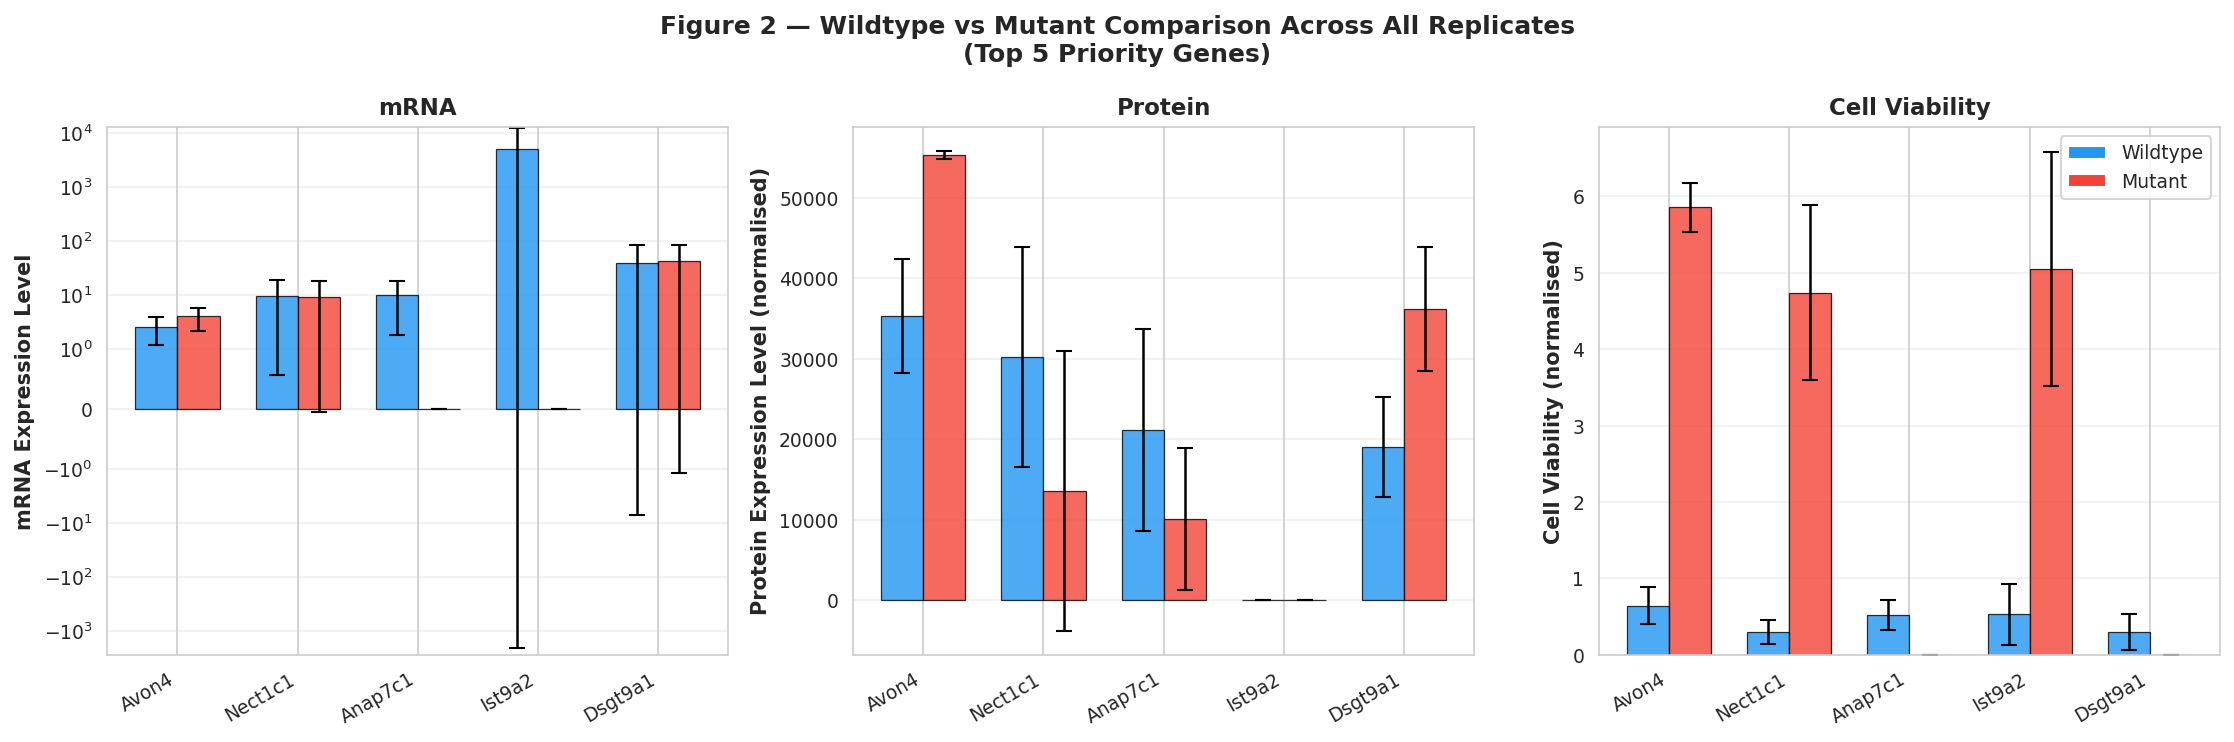

In [10]:
# FIGURE 2 — Replicate-level WT vs Mutant for Top 5 genes

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle(
    'Figure 2 — Wildtype vs Mutant Comparison Across All Replicates\n'
    '(Top 5 Priority Genes)',
    fontsize=12, fontweight='bold'
)

WT_COLOUR  = '#2196F3'   # Blue for wildtype
MUT_COLOUR = '#F44336'   # Red for mutant

modalities = [
    (
        'mRNA',
        ['mRNA.Expression.WT.Rep1',  'mRNA.Expression.WT.Rep2',  'mRNA.Expression.WT.Rep3'],
        ['mRNA.Expression.Mut.Rep1', 'mRNA.Expression.Mut.Rep2', 'mRNA.Expression.Mut.Rep3'],
        'mRNA Expression Level'
    ),
    (
        'Protein',
        ['Protein.Expression.WT.Rep1',  'Protein.Expression.WT.Rep2',  'Protein.Expression.WT.Rep3'],
        ['Protein.Expression.Mut.Rep1', 'Protein.Expression.Mut.Rep2', 'Protein.Expression.Mut.Rep3'],
        'Protein Expression Level (normalised)'
    ),
    (
        'Cell Viability',
        ['CellViability.WT.Rep1',  'CellViability.WT.Rep2',  'CellViability.WT.Rep3'],
        ['CellViability.Mut.Rep1', 'CellViability.Mut.Rep2', 'CellViability.Mut.Rep3'],
        'Cell Viability (normalised)'
    ),
]

for ax, (name, wt_cols, mut_cols, ylabel) in zip(axes, modalities):
    top5_data = master_df[master_df['Gene'].isin(TOP_5_GENES)].copy()
    x = np.arange(len(TOP_5_GENES))
    width = 0.35

    for i, gene in enumerate(TOP_5_GENES):
        row = top5_data[top5_data['Gene'] == gene].iloc[0]

       
        wt_vals  = [row[c] for c in wt_cols  if row[c] >= 0]
        mut_vals = [row[c] for c in mut_cols if row[c] >= 0]

        wt_mean  = np.mean(wt_vals)  if wt_vals  else 0
        mut_mean = np.mean(mut_vals) if mut_vals else 0
        wt_err   = np.std(wt_vals)   if len(wt_vals)  > 1 else 0
        mut_err  = np.std(mut_vals)  if len(mut_vals) > 1 else 0

        ax.bar(i - width/2, wt_mean,  width, color=WT_COLOUR,
               alpha=0.8, yerr=wt_err,  capsize=4,
               error_kw={'linewidth': 1.2},
               edgecolor='black', linewidth=0.6)
        ax.bar(i + width/2, mut_mean, width, color=MUT_COLOUR,
               alpha=0.8, yerr=mut_err, capsize=4,
               error_kw={'linewidth': 1.2},
               edgecolor='black', linewidth=0.6)

    ax.set_xticks(x)
    ax.set_xticklabels(TOP_5_GENES, rotation=30, ha='right', fontsize=9)
    ax.set_ylabel(ylabel, fontweight='bold')
    ax.set_title(f'{name}', fontweight='bold')
    ax.grid(axis='y', alpha=0.3)

   
    if name == 'mRNA':
        ax.set_yscale('symlog', linthresh=1)

# Shared legend
from matplotlib.patches import Patch
legend_handles = [
    Patch(facecolor=WT_COLOUR,  label='Wildtype'),
    Patch(facecolor=MUT_COLOUR, label='Mutant')
]
axes[-1].legend(handles=legend_handles, loc='upper right', framealpha=0.8)

plt.tight_layout()
plt.savefig('figure2_top5_wt_vs_mut.png', dpi=300, bbox_inches='tight')
print("Figure 2 saved.")
plt.show()

**Figure 2.** Wildtype (blue) vs mutant (red) expression levels for the top 5 priority genes, showing individual replicate means ± standard deviation. Three measurement modalities are shown: mRNA expression (left, symlog scale to handle near-zero values), protein expression (centre), and cell viability (right). Key observations: Avon4 shows consistent increases across all modalities; Ist9a2 protein and mRNA collapse to zero in all mutant replicates; Anap7c1 and Dsgt9a1 show zero viability across all mutant replicates (bars absent from right panel), confirming lethality.

Figure 3 saved → figure3_heatmap.png


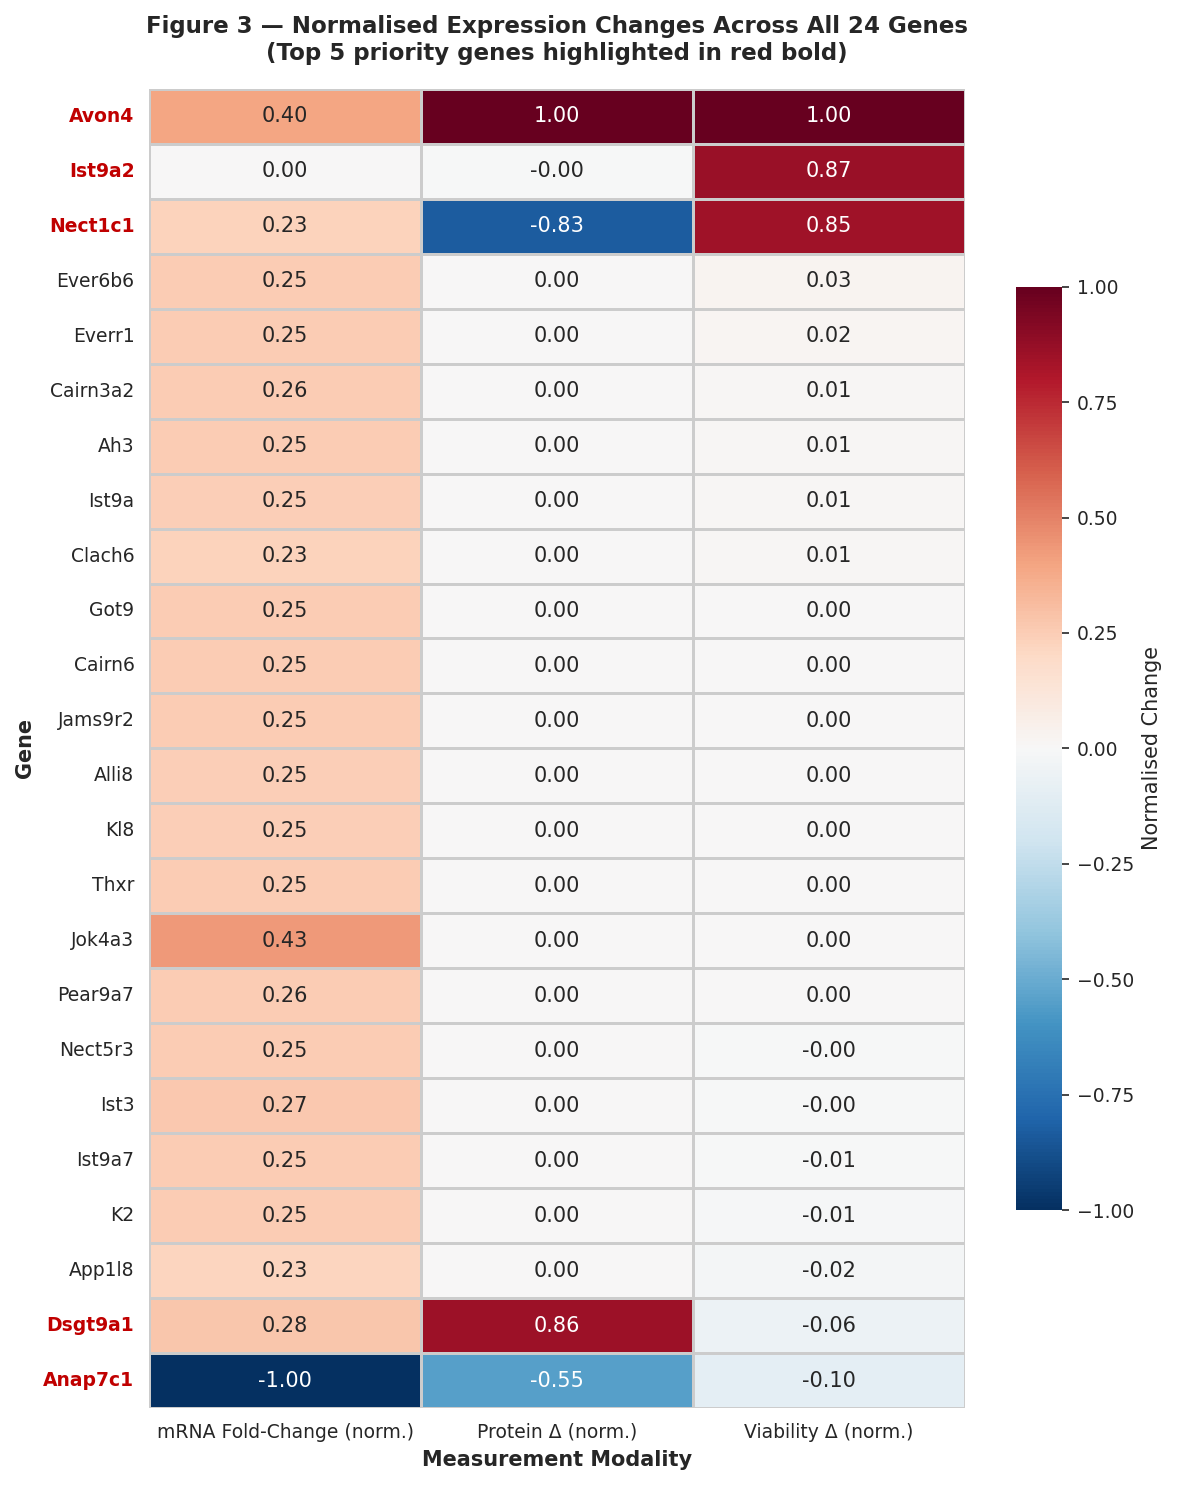

In [11]:
# FIGURE 3 — HEATMAP OF ALL GENES ACROSS ALL MODALITIES 

heat_df = master_df[['Gene','Mutation.Class','In.Promoter',
                       'mRNA.FoldChange','Protein.Diff','Viability.Diff']].copy()
heat_df = heat_df.set_index('Gene')

heat_data = heat_df[['mRNA.FoldChange','Protein.Diff','Viability.Diff']].copy()

for col in heat_data.columns:
    col_max = heat_data[col].abs().max()
    if col_max > 0:
        heat_data[col] = heat_data[col] / col_max

heat_data.columns = ['mRNA Fold-Change (norm.)', 'Protein Δ (norm.)', 'Viability Δ (norm.)']
heat_data = heat_data.sort_values('Viability Δ (norm.)', ascending=False)

fig, ax = plt.subplots(figsize=(8, 10))
sns.heatmap(
    heat_data,
    cmap='RdBu_r',
    center=0,
    vmin=-1, vmax=1,
    annot=True, fmt='.2f',
    linewidths=0.5,
    linecolor='#cccccc',
    cbar_kws={'label': 'Normalised Change', 'shrink': 0.7},
    ax=ax
)

for label in ax.get_yticklabels():
    if label.get_text() in TOP_5_GENES:
        label.set_fontweight('bold')
        label.set_color('#C00000')

ax.set_title('Figure 3 — Normalised Expression Changes Across All 24 Genes\n'
             '(Top 5 priority genes highlighted in red bold)',
             fontsize=11, fontweight='bold', pad=14)
ax.set_xlabel('Measurement Modality', fontweight='bold')
ax.set_ylabel('Gene', fontweight='bold')

plt.tight_layout()

plt.savefig('figure3_heatmap.png', dpi=300, bbox_inches='tight')

print("Figure 3 saved → figure3_heatmap.png")

plt.show()

**Figure 3.** Heatmap of normalised expression changes across all 24 genes. Each column represents one measurement modality (mRNA fold-change, protein absolute change, viability absolute change), normalised to [−1, +1] for comparability. Genes are sorted by viability change (top = largest increase). **Top 5 priority genes are highlighted in bold red.** The heatmap visually confirms that these five genes occupy the extreme ends of all three measurement dimensions, while the remaining 19 genes cluster near zero (white).

## 3. Results

### 3.1 Mutation Landscape

Of the 24 genes screened, mutations were classified as:
- **11 substitutions (sub)** — single nucleotide changes; the most common mutation type, though most produce only modest expression changes
- **7 deletions (del)** — ranging from −2 bp to −996 bp; include the two most dramatic phenotypes in the dataset
- **6 insertions (ins)** — ranging from +2 bp to +9 bp; include both promoter and coding-region frameshifts

**23 of 24 genes** carry mutations within the promoter region (first 1,000 bp), confirming that regulatory element disruption is the predominant mechanism across this dataset. The single exception is **Dsgt9a1**, whose +7 bp insertion falls exclusively within the coding region.

The distribution of mutation types by class is shown in Figure 1A (mRNA expression by mutation class) and Figure 1C (viability distribution by mutation class).

### 3.2 Top 5 Priority Genes

The five genes with the strongest and most consistent multi-layered molecular effects are presented in Table 1, with full replicate-level data shown in Figure 2 and global ranking in Figure 3.

| Rank | Gene | Mutation Type | In Promoter | mRNA Change | Protein Change | Viability Δ | Priority Score |
|------|------|---------------|-------------|-------------|----------------|-------------|----------------|
| 1 | **Avon4** | Insertion (+7 bp) | ✓ Yes | +57% | +56% (↑20,032 units) | **+5.22** | 0.930 |
| 2 | **Ist9a2** | Deletion (−996 bp) | ✓ Yes | −100% (→ zero) | −100% (→ zero) | **+4.51** | 0.869 |
| 3 | **Nect1c1** | Deletion (−5 bp) | ✓ Yes | −8% | −55% (↓16,614 units) | **+4.44** | 0.815 |
| 4 | **Anap7c1** | Substitution | ✓ Yes | Dysregulated (negative values) | −52% (↓11,077 units) | **−0.52 (lethal)** | 0.210 |
| 5 | **Dsgt9a1** | Insertion (+7 bp) | ✗ No (coding only) | +10% | +90% (↑17,158 units) | **−0.30 (lethal)** | 0.175 |

*Table 1. Top 5 priority genes ranked by composite priority score (see Methods 2.5). Δ = mutant mean − wildtype mean across three replicates.*

### 3.3 Key Biological Findings

**Cell viability** shows the clearest biological separation between priority and non-priority genes (Figure 1C). The top 3 genes (Avon4, Ist9a2, Nect1c1) show viability increases exceeding 4.4 units — more than 30-fold greater than any of the remaining 19 genes. Two genes (Anap7c1, Dsgt9a1) exhibit complete viability loss across all replicates, identifying them as essential gene candidates (Figure 2, right panel).

**Protein expression** is the most informative molecular marker for distinguishing top candidates from the background (Figure 1B, Figure 2 centre panel). Avon4 (+56%), Dsgt9a1 (+90%), and Nect1c1 (−55%) all show absolute protein changes exceeding 10,000 normalised units — more than 100-fold greater than the median gene in this dataset.

**mRNA expression** in Ist9a2 collapses to near-zero due to the near-complete promoter deletion (996 bp), representing a promoter-null phenotype visible in Figure 1A as an outlier within the deletion class. In contrast, Anap7c1 yields anomalous negative mRNA values across mutant replicates, indicating severe transcriptional dysregulation rather than simple downregulation — a qualitatively distinct phenotype from all other genes (Figure 3, top row).

The normalised heatmap in Figure 3 clearly illustrates that the top 5 genes (highlighted in red bold) occupy the extremes of all three measurement dimensions simultaneously, while the remaining 19 genes cluster near zero change.

## 4. Discussion

### 4.1 Why These Five Genes — The Biological Case

The selection of these five genes is not simply a matter of choosing the largest numbers. Each gene tells a distinct and biologically coherent story that connects mutation type, genomic location, molecular phenotype, and therapeutic relevance.

**Avon4 — Gain-of-function through promoter insertion**  
The +7 bp insertion in the Avon4 promoter simultaneously increases mRNA (+57%), protein (+56%), and cell viability (+5.22 units). This coherent upregulation across all three molecular layers is strong evidence that the insertion enhances transcription factor binding affinity or creates a new binding site entirely — a classic promoter gain-of-function. This is particularly relevant to Commenticius's bioremediation portfolio, where enhanced microbial fitness and gene expression are desirable. Avon4 should be prioritised for promoter binding assays (e.g., EMSA or ChIP) to characterise the regulatory element created.

**Ist9a2 — Promoter-null phenotype reveals a fitness-suppressing gene**  
The 996 bp deletion removes virtually the entire promoter of Ist9a2, silencing the gene completely (mRNA → 0, protein → 0). Critically, this silencing *improves* cell viability by 9-fold. This counterintuitive result has a clear biological interpretation: the wildtype Ist9a2 product actively suppresses cell fitness under these conditions — it may encode a toxin, a stress-response repressor, or a factor that redirects cellular resources away from growth. From a therapeutic standpoint, this is an ideal drug target profile: an inhibitor of Ist9a2 expression or function would phenocopy the beneficial deletion. This pattern is consistent with conditionally dispensable or actively harmful genes in pathogen biology.

**Nect1c1 — Post-transcriptional regulation revealed by mRNA–protein discordance**  
Nect1c1 presents the most mechanistically interesting pattern in the dataset: mRNA changes by only −8% but protein drops by 55% (from ~30,210 to ~13,596 units). This dissociation between transcriptional and translational output is a hallmark of post-transcriptional regulation. The most likely explanations are: (i) the 5 bp promoter deletion alters the 5' UTR structure, reducing ribosome recruitment efficiency; (ii) the deletion creates or destroys an upstream open reading frame (uORF) that sequesters ribosomes; or (iii) the resulting mRNA has altered secondary structure affecting translation initiation. The dramatic viability gain (WT ~0.30 → Mut ~4.74) despite relatively modest mRNA change confirms that protein-level silencing is the functional effector, not transcriptional repression. This mechanistic complexity — and the divergence between mRNA and protein — makes Nect1c1 a particularly valuable research target and demonstrates the importance of measuring all three molecular layers, not mRNA alone.

**Anap7c1 — Essential gene identified through promoter sensitivity**  
Anap7c1 exhibits the most extreme phenotype in the dataset: a single nucleotide substitution in the promoter is sufficient to reduce cell viability to exactly zero across all three replicates. The complete and reproducible lethality across independent replicates strongly implies that this gene is essential — its product is required for survival under the experimental conditions. Furthermore, protein expression is halved (−52%) and mRNA yields negative values (an artefact of extreme downregulation below the assay background), indicating the substitution severely disrupts promoter activity. The fact that such a minor mutation (one base change) produces such a severe phenotype suggests the affected nucleotide lies within a critical transcription factor binding motif — perhaps a TATA box, initiator element, or upstream activating sequence. Essential genes are the gold standard for antibiotic and antifungal drug targets, because any drug that disrupts this promoter element would be lethal to the pathogen.

**Dsgt9a1 — Toxic gain-of-function through coding frameshift**  
Dsgt9a1 is mechanistically distinct from the other four genes because its mutation lies in the coding region, not the promoter. The +7 bp insertion causes a frameshift, which would be expected to alter the reading frame of all codons downstream of the insertion site. Despite — or perhaps because of — this disruption, protein expression measured by the protein array nearly doubles (+90%, from ~19,030 to ~36,189 units). This elevated protein alongside complete viability loss (all three replicates = 0) is characteristic of a **dominant-negative** or **gain-of-toxic-function** mutation: the frameshifted protein accumulates (perhaps because it evades normal degradation signals encoded in the altered C-terminus) but is functionally aberrant and lethal, possibly by interfering with an essential protein complex or membrane system. This phenotype makes Dsgt9a1 particularly interesting for structural biology and inhibitor design — the toxic protein itself could serve as a drug target.

### 4.2 Why the Remaining 19 Genes Were Not Selected

It is equally important to justify why genes were *excluded*. The 19 non-priority genes all share the following characteristics:
- Absolute cell viability change < 0.14 units (vs. >0.30 for all top 5)
- Absolute protein change < 100 units (vs. >11,000 for all top 5)
- mRNA fold-change within 10–15% of wildtype (vs. >50% for top 5)

These changes are consistent with **neutral or near-neutral mutations** — small sequence changes that do not meaningfully alter gene function. Many may represent synonymous substitutions at the protein level, or mutations at non-functional positions within the promoter. Prioritising these genes would be a poor use of Commenticius's experimental resources.

### 4.3 Limitations and Future Work

- **Statistical power:** With only three biological replicates, formal significance testing has limited power. The t-test results confirm directional consistency but independent biological confirmation with expanded replication (n ≥ 6) is recommended before committing to these targets.
- **Negative mRNA values:** Anap7c1 mutant replicates yield negative mRNA expression values, which are physically impossible and represent measurement noise below the assay's lower detection limit. These are handled defensively in the analysis (excluded from mean calculations where negative) but should be re-measured with a more sensitive qRT-PCR assay.
- **Gene function unknown:** This analysis is agnostic to gene function. Gene Ontology (GO) annotation and BLAST homology searches should be conducted on all five priority genes to contextualise their molecular roles before committing to therapeutic development.
- **Single assay condition:** All measurements were performed under one experimental condition. Some mutations may be conditionally lethal or beneficial; testing across multiple growth conditions would strengthen confidence in the top 5 selection.

## 5. Conclusions

This analysis integrated mRNA expression, protein expression, and cell viability data for 24 gene mutations to identify the five most promising candidates for experimental validation:

1. **Avon4** — promoter insertion; strong gain-of-function across all modalities
2. **Ist9a2** — near-total promoter deletion; complete gene silencing with viability gain
3. **Nect1c1** — small promoter deletion; large protein loss with viability gain
4. **Anap7c1** — promoter substitution; lethal phenotype (essential gene candidate)
5. **Dsgt9a1** — coding frameshift; toxic gain-of-function (essential gene candidate)

These five genes span three mutation types (substitution, insertion, deletion), both promoter and coding regions, and both gain- and loss-of-function phenotypes — providing a diverse and complementary set of leads for Commenticius's therapeutic and bioremediation pipelines.


### Code Availability

All analysis code is publicly available on GitHub:  
**Repository:** `https://github.com/pharmaco-tech/BT5511--Gene-Mutation-Analysis-52534825.git`

## APPENDIX: AI Usage Declaration

#### Tool Used: Claude AI (Anthropic, claude.ai)  

---

### 1. Data Loading and File Discovery  

I wrote the initial file-loading loop myself using `glob` and `pd.read_csv`, which I learned from the workshop notebooks. I structured the for loop and concatenation logic on my own.  

**Where I asked AI for help**:  
My initial code crashed when one file had an unexpected number of columns during testing. I asked Claude:  
**Prompt**:  
*"My pd.read_csv loop crashes if a file is malformed. How do I add a try/except block to skip bad files gracefully?"*  
AI explained the try/except pattern. I then wrote the `load_gene_file()` function myself incorporating that pattern and added the column count check as my own defensive measure.

---

### 2. Mutation Classification with Regular Expressions  

I understood that sequence length comparison could classify insertions and deletions (longer mutant = insertion, shorter = deletion, same length = substitution). I wrote this logic myself.

**Where I asked AI for help**:  
I was unsure how to use `re` (regular expressions) to scan for nucleotide mismatches in substitutions. I asked:  
**Prompt**:  
*"How do I use Python's re module to match only valid DNA bases [ACGT] when comparing two sequences character by character?"*  
AI showed me `re.compile(r'[ACGT]')`. I integrated this into my own `classify_mutation()` function around logic I had already written.

---

### 3. Summary Statistics  
 
I calculated the means and standard deviations across replicates myself using `.mean(axis=1)` and `.std(axis=1)`. I also independently calculated fold-changes (mutant ÷ wildtype) and absolute differences.

**Where I asked AI for help**:  
I encountered a division-by-zero error when a wildtype mRNA value was 0 (seen in `Ist9a2`). I asked:  
**Prompt**:  
*"How do I prevent division by zero when calculating a fold-change ratio in pandas without removing the row?"*  
AI suggested adding a small constant (+ 1e-9) to the denominator. I applied this fix myself across all fold-change calculations.

---

### 4. Gene Prioritisation and Scoring  
 
I decided independently that the three most important criteria were cell viability change, protein expression change, and mRNA fold-change — because these directly reflect phenotypic and molecular impact. I also chose the weighting (40% viability, 30% protein, 30% mRNA) based on biological reasoning: phenotypic effects are the most direct evidence of a mutation's impact.

**Where I asked AI for help**:  
I asked how to normalize metrics to a common scale so they could be combined fairly:  
**Prompt**:  
*"How do I normalize multiple pandas columns to a 0–1 range so I can combine them into a composite score?"*  
AI explained **min-max normalization**. I wrote the `min_max_normalise()` function myself and applied it with my own weights.

---

### 5. Data Visualisation  
 
I chose which panels to include in Figure 1 (boxplot, scatter, KDE, bar chart) based on the example graph in the brief. I independently decided to use log scales on the boxplot and scatter plot, as these were shown in the example. I chose which genes to highlight in red and wrote the annotation loop myself.

**Where I asked AI for help**:  
I had two specific visualization problems:  
**Problem 1 — Subplot layout**:  
**Prompt**:  
*"How do I use GridSpec in matplotlib to create a 2×2 subplot layout with custom spacing?"*  
**Problem 2 — KDE plot**:  
**Prompt**:  
*"How do I plot a kernel density estimate in matplotlib using scipy's gaussian_kde for each mutation class?"*  
AI provided the syntax for both. I then customized colors, labels, titles, axis scales, and figure layout myself.

---
